<a href="https://colab.research.google.com/github/edgaryoungpilo-web/colab-files/blob/main/Practica_21_266659.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Ejercicio 1: Normalización Min-Max

1.	Cargar el dataset wine de sklearn.


```python
from sklearn.datasets import load_wine
# Load the dataset
wine = load_wine()
X = wine.data
y = wine.target
```


2.	Seleccionar una de las características numéricas (por ejemplo, alcohol).
3.	Realizar una prueba de normalidad (usando scipy.stats.shapiro) sobre los datos originales.
4.	Aplicar la normalización Min-Max a los datos seleccionados.
5.	Realizar la prueba de normalidad nuevamente sobre los datos normalizados.
6.	Graficar los datos originales y los normalizados utilizando matplotlib o seaborn.
7.	Responder las preguntas siguientes.

Preguntas:
1. ¿Cómo afectó la normalización Min-Max a la distribución de los datos?
2. ¿Qué interpretas del p-valor antes y después de la normalización?


In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Ejercicio 2: Normalización Z-Score

Instrucciones:
1. Cargar el dataset wine de sklearn.
2. Seleccionar una de las características numéricas (por ejemplo, malic_acid).
3. Realizar una prueba de normalidad (usando scipy.stats.shapiro) sobre los datos originales.
4. Aplicar la normalización Z-Score a los datos seleccionados.
5. Realizar la prueba de normalidad nuevamente sobre los datos normalizados.
6. Graficar los datos originales y los normalizados utilizando matplotlib o seaborn.
7. Responder las preguntas siguientes.

Preguntas:
1. ¿Qué diferencia observas entre la distribución original y la normalizada con Z-Score?
2. ¿Qué implicaciones tiene la normalización Z-Score en el análisis de los datos?



#Ejercicio 3: Transformación Logarítmica
Instrucciones:
1. Cargar un conjunto de datos aleatorios generados con numpy:
    - Número de observaciones = 1000;
    - Valor de semilla = `np.random.seed(42)`
    - Distribucion exponencial: `np.random.exponential(scale=2, size=1000)`
2. Aplicar una transformación logarítmica (np.log) a los datos.
3. Realizar una prueba de normalidad sobre los datos originales y transformados.
4. Graficar los datos originales y transformados utilizando matplotlib.
5. Responder las preguntas siguientes.

Preguntas:
1. ¿Cómo afectó la transformación logarítmica a la distribución de los datos?
2. ¿Qué interpretas del p-valor antes y después de la transformación logarítmica?


#Ejercicio 4: Transformación Raíz Cuadrada
Instrucciones:
1. Cargar un conjunto de datos aleatorios generados con numpy.
    - Número de observaciones: 1000
    - Semilla = `np.random.seed(42)``
    - Distribución Poisson: `np.random.poisson(lam=5, size=1000)`
2. Aplicar una transformación de raíz cuadrada a los datos.
3. Realizar una prueba de normalidad sobre los datos originales y transformados.
4. Graficar los datos originales y transformados utilizando matplotlib.
5. Responder las preguntas siguientes.

Preguntas:
1. ¿Cómo afectó la transformación raíz cuadrada a la distribución de los datos?
2. ¿Qué efectos tiene la raíz cuadrada sobre los valores extremos de los datos?


#Ejercicio 5: Transformación Box-Cox
Instrucciones:
1. Cargar un conjunto de datos aleatorios generados con numpy.
    - Numero de observaciones: 1000
    - Semilla: `np.random.seed(42)``
    - Distribución log-normal: `np.random.lognormal(mean=1, sigma=0.8, size=1000)`
2. Aplicar la transformación Box-Cox a los datos utilizando scipy.stats.boxcox.
3. Realizar una prueba de normalidad sobre los datos originales y transformados.
4. Graficar los datos originales y transformados utilizando matplotlib.
5. Responder las preguntas siguientes.

Preguntas:
1. ¿Cómo afectó la transformación Box-Cox a la distribución de los datos?
2. ¿Qué interpretación tiene el valor lambda obtenido en la transformación Box-Cox?


# Solucion Ejercicio 1. Normalizaion Min-Max

Original p-value: 0.020047981728854945
Normalizado p-value: 0.020047981728854858


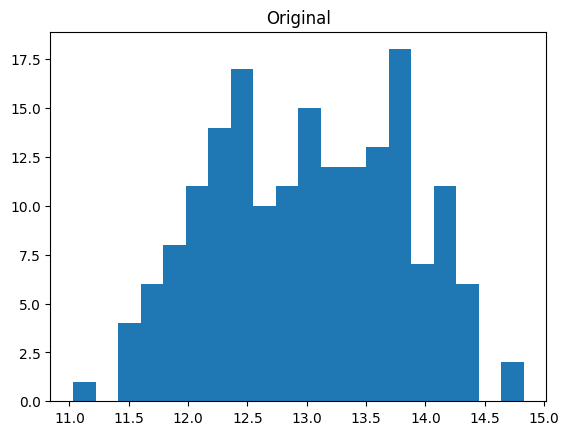

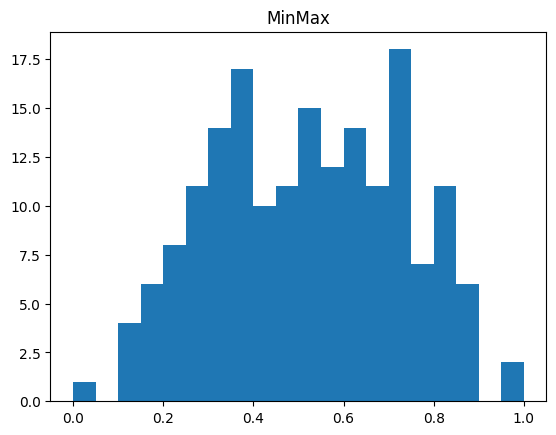

In [12]:
from sklearn.datasets import load_wine
from sklearn.preprocessing import MinMaxScaler
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import pandas as pd

# Cargar datos
wine = load_wine()
X = pd.DataFrame(wine.data, columns=wine.feature_names)

# Seleccionar variable
data = X['alcohol']

# Prueba de normalidad original
stat1, p1 = shapiro(data)

# Normalización MinMax
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data.values.reshape(-1,1)).flatten()

# Prueba después
stat2, p2 = shapiro(data_scaled)

# Resultados
print("Original p-value:", p1)
print("Normalizado p-value:", p2)

# Gráficas
plt.figure()
plt.hist(data, bins=20)
plt.title("Original")
plt.show()

plt.figure()
plt.hist(data_scaled, bins=20)
plt.title("MinMax")
plt.show()

Conclusion:

Si p<0.05 = No es normal

*   Si p<0.05 = No es normal
*   Min-Max no cambia la forma, solo escala

# Solucion Ejercicio 2: Normalización Z-Score

Original p: 2.945800703600761e-10
Z-score p: 2.9458007036005247e-10


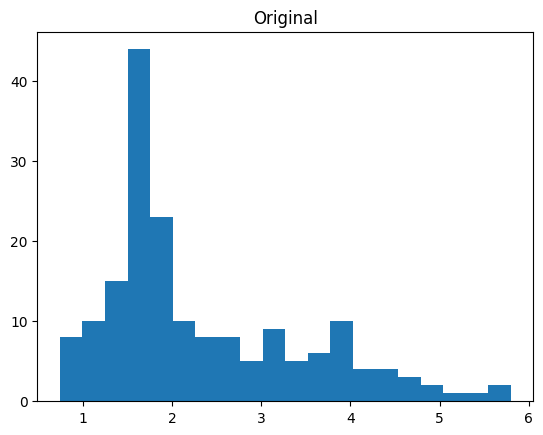

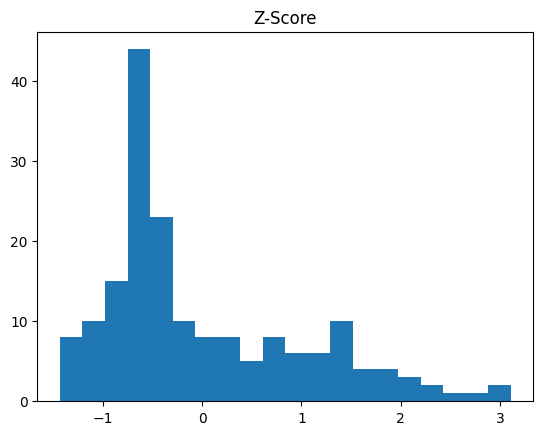

In [13]:
from sklearn.preprocessing import StandardScaler

data = X['malic_acid']

# Normalidad original
stat1, p1 = shapiro(data)

# Z-score
scaler = StandardScaler()
data_std = scaler.fit_transform(data.values.reshape(-1,1)).flatten()

# Normalidad después
stat2, p2 = shapiro(data_std)

print("Original p:", p1)
print("Z-score p:", p2)

# Gráficas
plt.figure()
plt.hist(data, bins=20)
plt.title("Original")
plt.show()

plt.figure()
plt.hist(data_std, bins=20)
plt.title("Z-Score")
plt.show()

Conclusion:


*   Centra en medio 0
*   Tampoco hace magicamente normal la distribucion



# Solucion Ejercicio 3: Transformación Logarítmica

Original p: 1.094865579608503e-31
Log p: 1.3218330609682656e-16


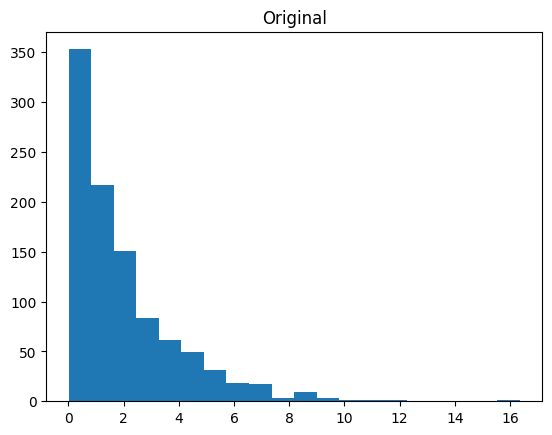

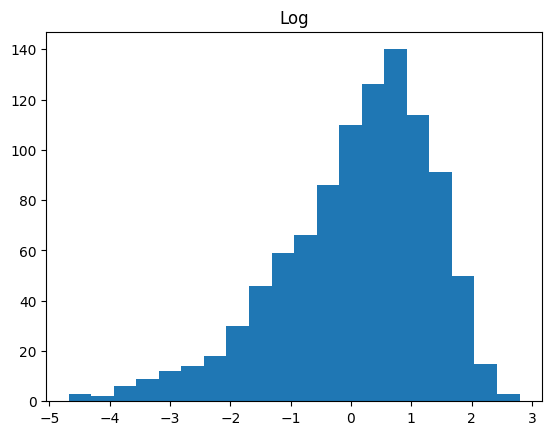

In [14]:
import numpy as np

np.random.seed(42)
data = np.random.exponential(scale=2, size=1000)

# Log
data_log = np.log(data)

# Shapiro
p1 = shapiro(data)[1]
p2 = shapiro(data_log)[1]

print("Original p:", p1)
print("Log p:", p2)

# Gráficas
plt.figure()
plt.hist(data, bins=20)
plt.title("Original")
plt.show()

plt.figure()
plt.hist(data_log, bins=20)
plt.title("Log")
plt.show()

Conclusion:


*   Log reduce asimetria
*   Mejora la normalidad



# Solucion Ejercicio 4: Raiz Cuadrada

Original p: 6.523300091890513e-13
Sqrt p: 5.668642183851904e-14


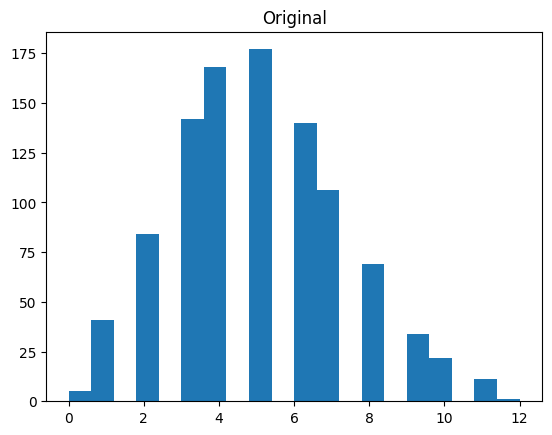

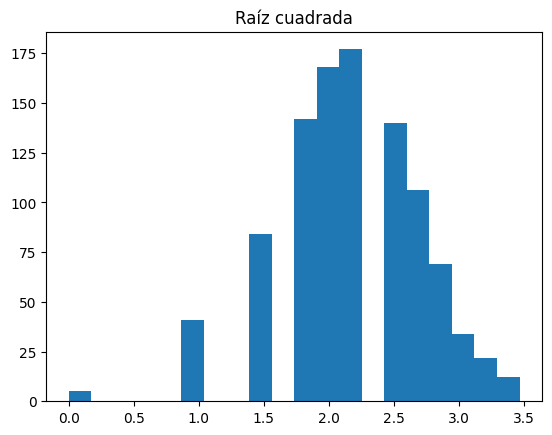

In [15]:
np.random.seed(42)
data = np.random.poisson(lam=5, size=1000)

# Transformación
data_sqrt = np.sqrt(data)

# Shapiro
p1 = shapiro(data)[1]
p2 = shapiro(data_sqrt)[1]

print("Original p:", p1)
print("Sqrt p:", p2)

# Gráficas
plt.figure()
plt.hist(data, bins=20)
plt.title("Original")
plt.show()

plt.figure()
plt.hist(data_sqrt, bins=20)
plt.title("Raíz cuadrada")
plt.show()

Conclusion:

*   Reduce Dispercion
*   Es util para conteos



#Solucion Ejercicio 5: Transformación Box-Cox

Original p: 6.966496130945429e-41
BoxCox p: 0.9891215954703348


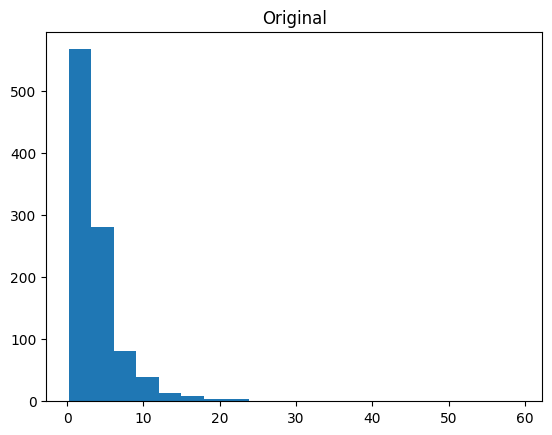

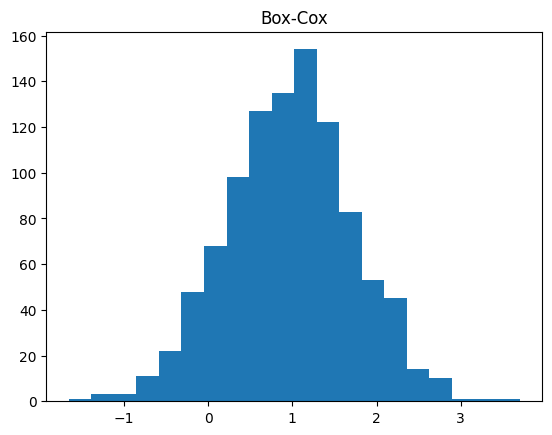

In [16]:
from scipy.stats import boxcox

np.random.seed(42)
data = np.random.lognormal(mean=1, sigma=0.8, size=1000)

# Box-Cox (requiere positivos)
data_boxcox, _ = boxcox(data)

# Shapiro
p1 = shapiro(data)[1]
p2 = shapiro(data_boxcox)[1]

print("Original p:", p1)
print("BoxCox p:", p2)

# Gráficas
plt.figure()
plt.hist(data, bins=20)
plt.title("Original")
plt.show()

plt.figure()
plt.hist(data_boxcox, bins=20)
plt.title("Box-Cox")
plt.show()

Conclusion:


*   Es la mejor trasnformacion para normalizar
*   Ajusta automaticmente la forma

